#  Problem Statement 

> The objective of this project is to classify penguin species using machine learning techniques based on physical characteristics such as culmen length, culmen depth, flipper length, body mass, island, and sex.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('penguins_size.csv')
data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
data.shape

(344, 7)

In [5]:

data.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
data.isnull().sum()/len(data)

species              0.000000
island               0.000000
culmen_length_mm     0.005814
culmen_depth_mm      0.005814
flipper_length_mm    0.005814
body_mass_g          0.005814
sex                  0.029070
dtype: float64

In [7]:
data['sex'].isnull().sum()

np.int64(10)

In [8]:
sex_mode_value = data['sex'].mode()[0]
data['sex'] = data['sex'].fillna(sex_mode_value)

In [9]:
data['sex'].isnull().sum()

np.int64(0)

In [10]:
print(data['sex'].unique())

['MALE' 'FEMALE' '.']


In [11]:
data['sex'] = data['sex'].replace('.', sex_mode_value)

print("Unique values in 'sex' column after replacement:")
print(data['sex'].unique())

Unique values in 'sex' column after replacement:
['MALE' 'FEMALE']


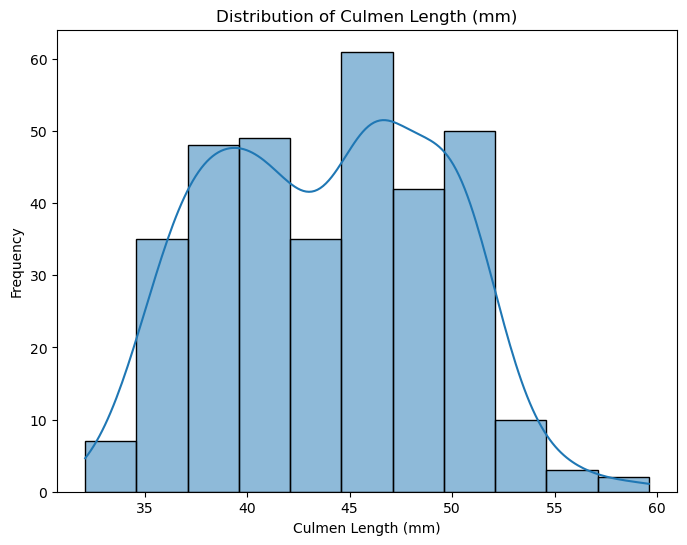

In [12]:
plt.figure(figsize=(8, 6))
sns.histplot(data['culmen_length_mm'].dropna(), kde=True)
plt.title('Distribution of Culmen Length (mm)')
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Frequency')
plt.show()

In [13]:
for col in ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']:
  data[col] = data[col].fillna(data[col].mean())

# Verify that there are no more missing values in these columns
print("\nMissing values after imputation:")
print(data[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']].isnull().sum())


Missing values after imputation:
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
dtype: int64


In [14]:
data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,MALE
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,FEMALE
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,FEMALE
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,MALE
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,FEMALE


In [15]:
data.duplicated().sum()

np.int64(0)

## Data Cleaning Summary

All missing values in the dataset were successfully handled:
*   Missing values in the 'sex' column were imputed using the mode.
*   Missing values in numerical columns (`culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`) were imputed using the mean.

Additionally, duplicate rows were checked, and **no duplicate values were found**. The dataset is now clean and ready for further analysis and model training

In [21]:
data.to_csv('Cleaned_DataSet.csv',index=False)

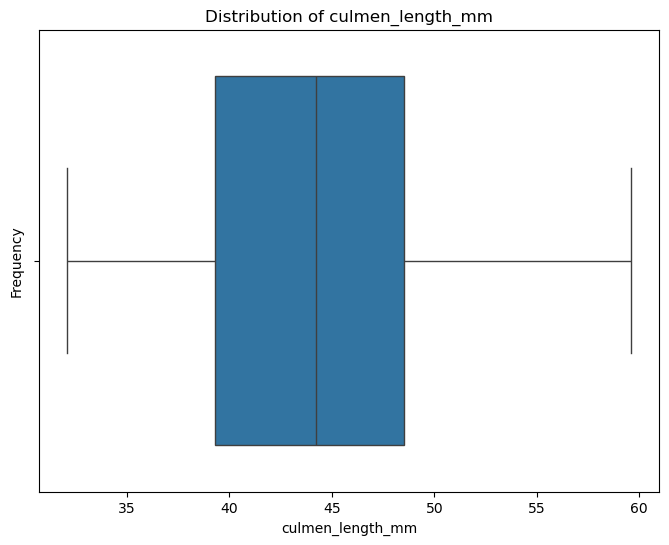

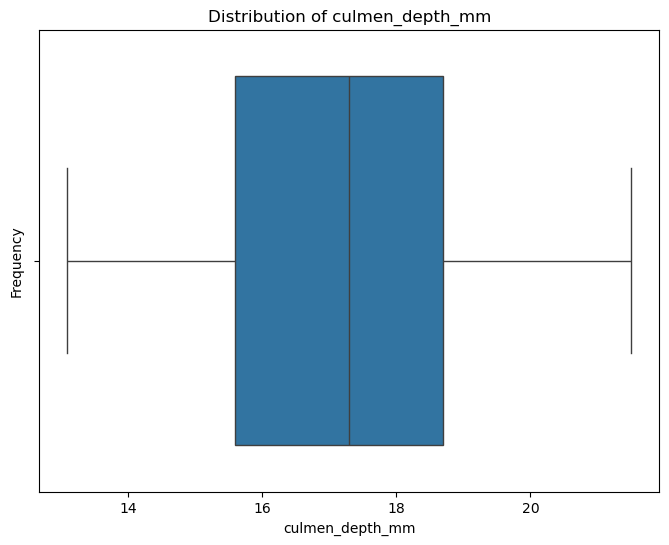

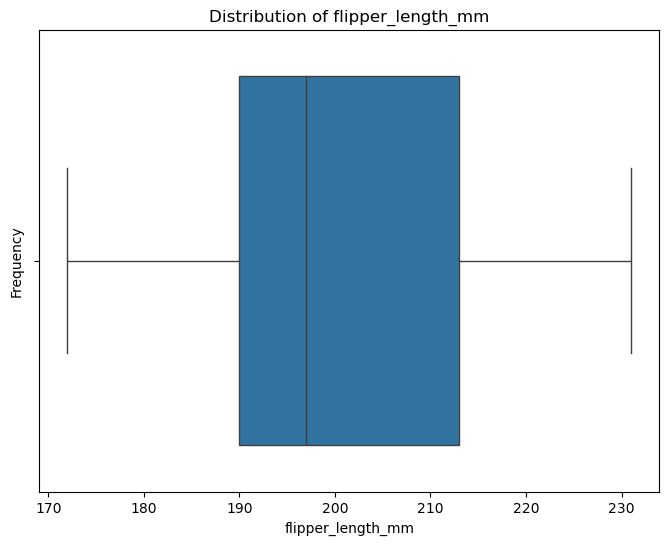

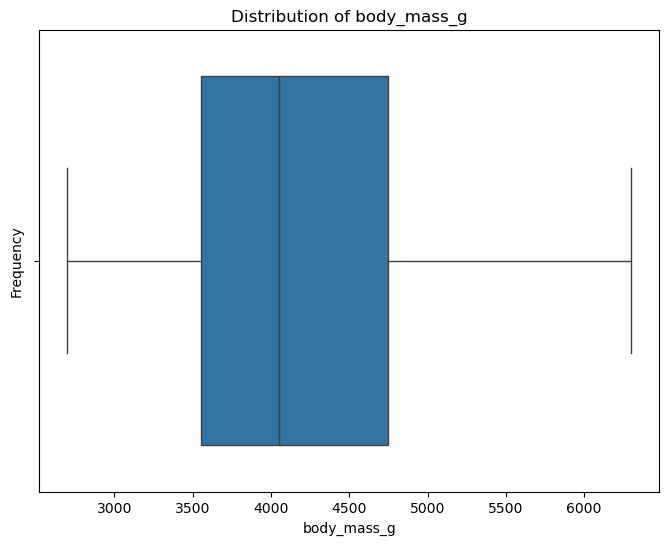

In [16]:
columns_to_plot = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in columns_to_plot :
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=data, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Outlier Analysis

Based on the boxplot analysis of the numerical features (`culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`), no major outliers were observed. This indicates that the dataset is relatively clean and suitable for further analysis and model training.

**Univariate analysis**



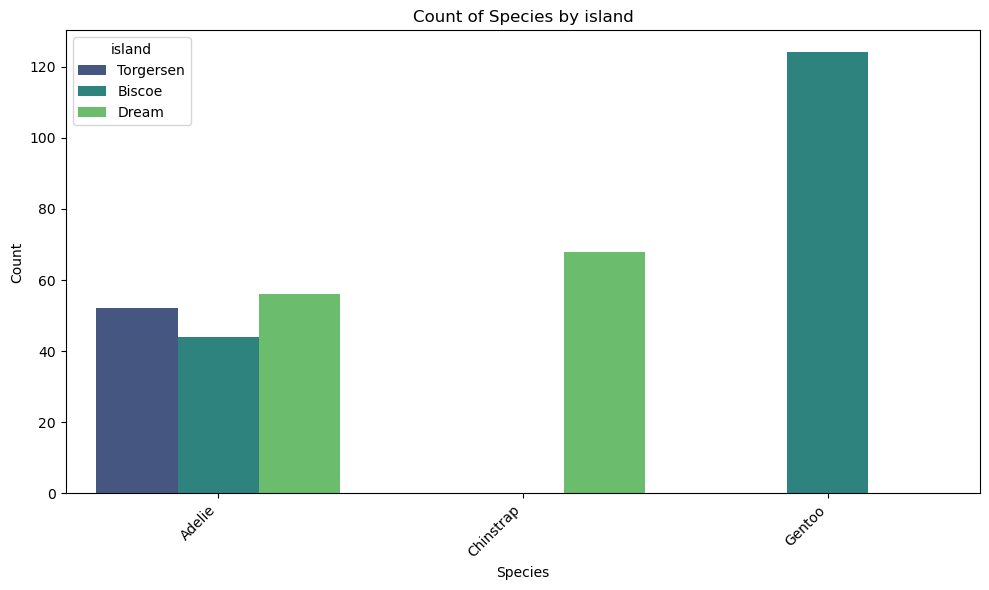

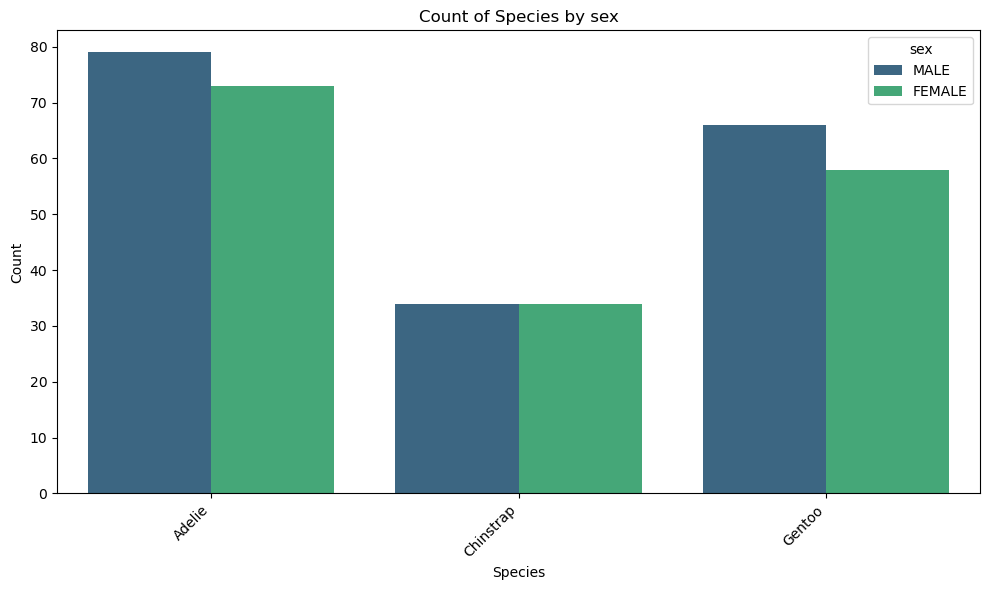

In [17]:
for column in data.columns:
    if data[column].dtype == 'object' and column != 'species':
        plt.figure(figsize=(10, 6))
        sns.countplot(x='species', hue=column, data=data, palette='viridis')
        plt.title(f'Count of Species by {column}')
        plt.ylabel('Count')
        plt.xlabel('Species')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

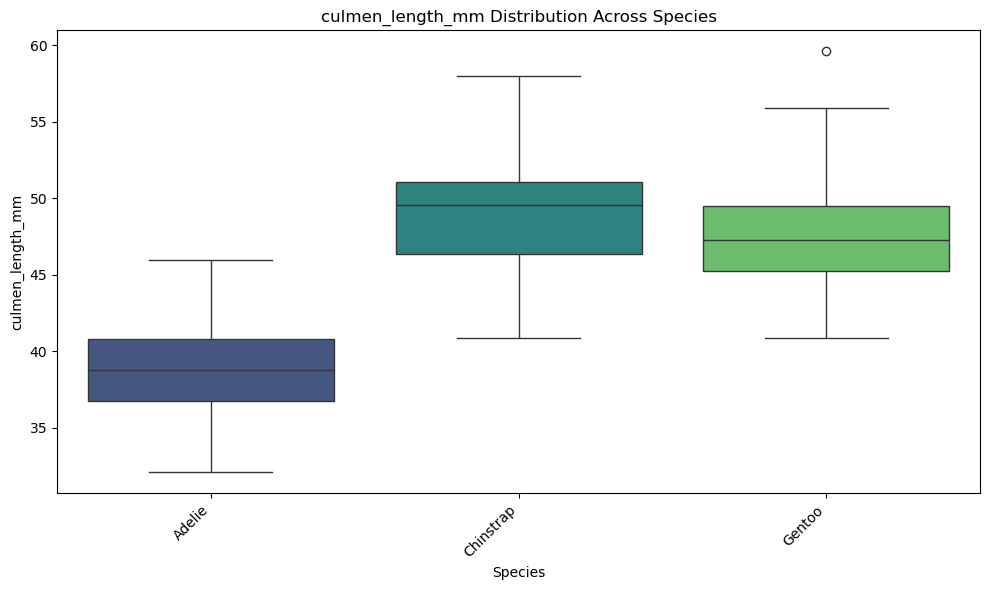

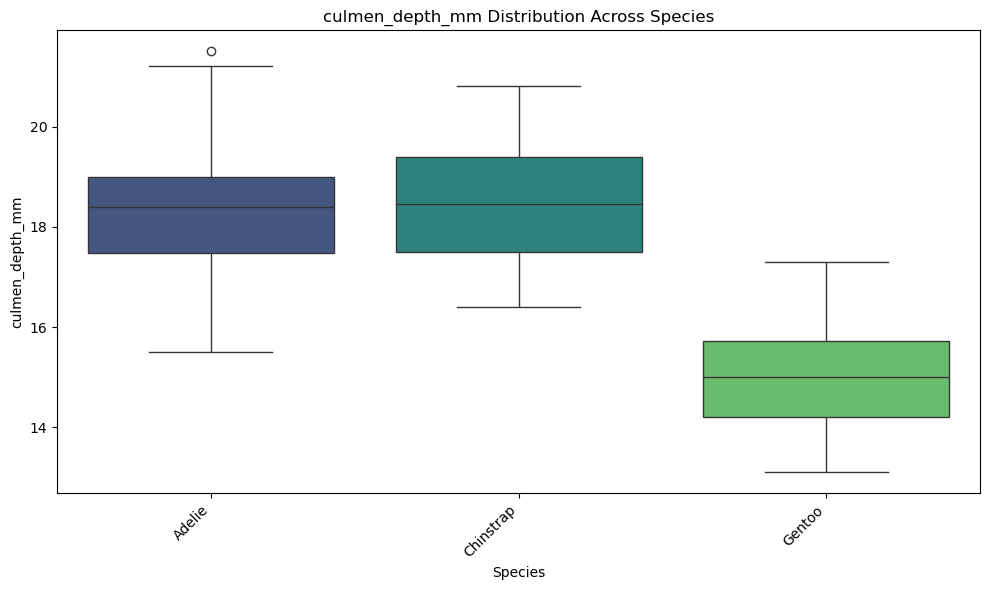

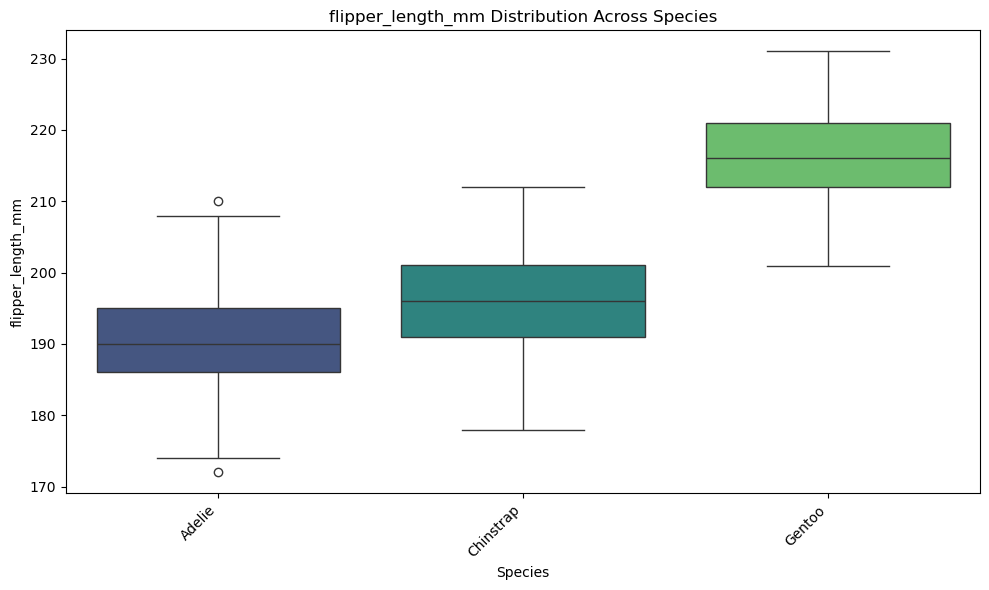

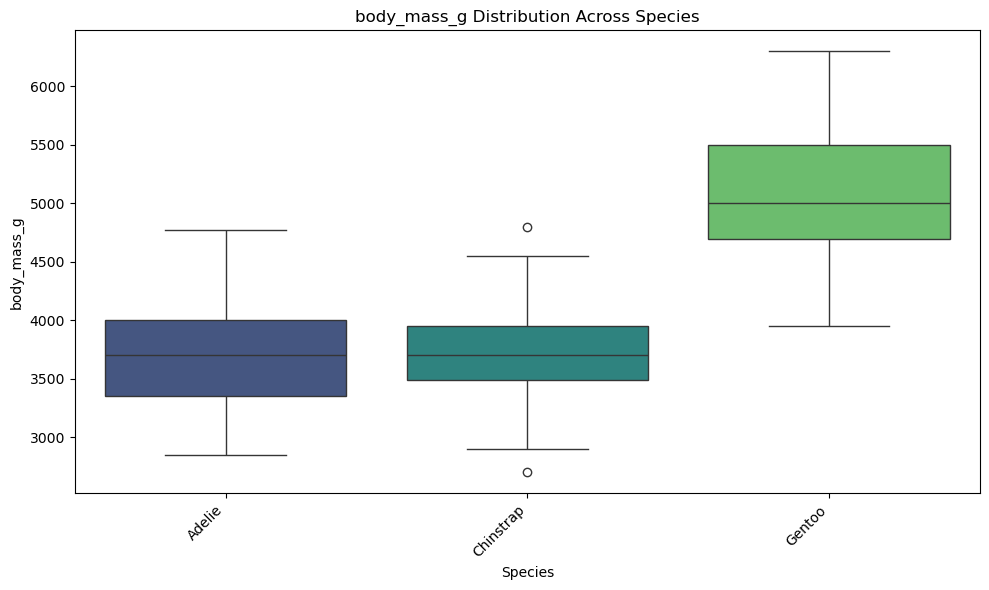

In [18]:
for column in data.columns:
  if data[column].dtype != 'object' and column != 'species':
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='species', y=column, data=data, palette='viridis',hue='species',legend=False)
    plt.title(f'{column} Distribution Across Species')
    plt.ylabel(column)
    plt.xlabel('Species')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

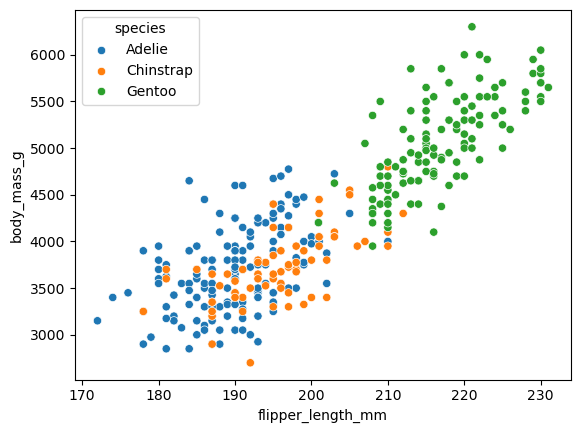

In [19]:
sns.scatterplot(x='flipper_length_mm', y='body_mass_g', hue='species', data=data)

<Axes: >

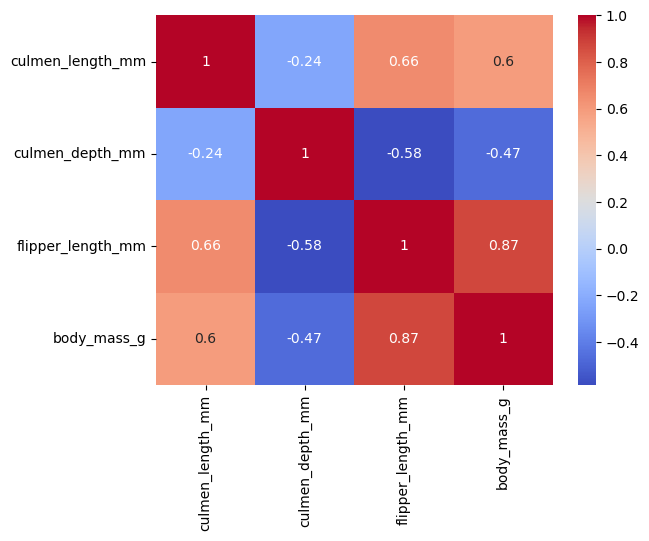

In [20]:
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [22]:
data.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


## Encoding Categorical Features

In [23]:
data['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Encoded_Species']= le.fit_transform(data['species'])

In [25]:
for i,label in enumerate(le.classes_):
  print(i,label)

0 Adelie
1 Chinstrap
2 Gentoo


In [26]:
data.drop('species',axis=1,inplace=True)

In [27]:
data = pd.get_dummies(data, columns=['island', 'sex'], drop_first=True)

display(data.head())

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,Encoded_Species,island_Dream,island_Torgersen,sex_MALE
0,39.10000,18.70000,181.000000,3750.000000,0,False,True,True
1,39.50000,17.40000,186.000000,3800.000000,0,False,True,False
2,40.30000,18.00000,195.000000,3250.000000,0,False,True,False
3,43.92193,17.15117,200.915205,4201.754386,0,False,True,True
4,36.70000,19.30000,193.000000,3450.000000,0,False,True,False


After encoding, the species column was replaced with Encoded_Species, which stores the numerical labels. The categorical columns island and sex were converted into one-hot encoded binary columns such as ( `island_Biscoe`, `sex_MALE`). `drop_first=True` was used to avoid multicollinearity and reduce redundant features

In [28]:
data.to_csv('Encoded_DataSet.csv',index=False)

## Separating Target and Feature Columns

In [27]:
x = data.drop('Encoded_Species', axis=1)
y = data['Encoded_Species']

print("Features (x) and target (y) have been separated successfully.")
print(f"Shape of X: {x.shape}")
print(f"Shape of y: {y.shape}")

display(x.head())
display(y.head())

Features (x) and target (y) have been separated successfully.
Shape of X: (344, 7)
Shape of y: (344,)


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.10000,18.70000,181.000000,3750.000000,False,True,True
1,39.50000,17.40000,186.000000,3800.000000,False,True,False
2,40.30000,18.00000,195.000000,3250.000000,False,True,False
3,43.92193,17.15117,200.915205,4201.754386,False,True,True
4,36.70000,19.30000,193.000000,3450.000000,False,True,False


0    0
1    0
2    0
3    0
4    0
Name: Encoded_Species, dtype: int64

## Train Test Split

In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
display(x_train.head())
display(y_train.head())

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
66,35.5,16.2,195.0,3350.0,False,False,False
229,46.8,15.4,215.0,5150.0,False,False,True
7,39.2,19.6,195.0,4675.0,False,True,True
140,40.2,17.1,193.0,3400.0,True,False,False
323,49.1,15.0,228.0,5500.0,False,False,True


66     0
229    2
7      0
140    0
323    2
Name: Encoded_Species, dtype: int64

In [29]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc =sc.transform(x_test)

In [30]:
display(x_train_sc)

array([[-1.51790052, -0.43753238, -0.43352258, ..., -0.75      ,
        -0.40651474, -1.01835015],
       [ 0.53915607, -0.84256773,  0.97077264, ..., -0.75      ,
        -0.40651474,  0.98198051],
       [-0.84435102,  1.28386784, -0.43352258, ..., -0.75      ,
         2.45993538,  0.98198051],
       ...,
       [-0.95357526,  0.0687618 , -0.15266354, ..., -0.75      ,
        -0.40651474, -1.01835015],
       [ 0.50274799, -1.45012075,  0.61969883, ..., -0.75      ,
        -0.40651474, -1.01835015],
       [-1.11741163, -0.53879122, -1.27609971, ..., -0.75      ,
        -0.40651474, -1.01835015]])

Now that the dataset has been cleaned, encoded, and scaled, the next step is to build machine learning models. The models will be trained using the prepared training data and then evaluated on test data to measure their prediction performance.


## Model Training

In [31]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)

lr.fit(x_train_sc,y_train)

LogisticRegression(random_state=42)

In [32]:
lr_pred = lr.predict(x_test_sc)

In [33]:
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report
print('Accuracy Score: ',accuracy_score(y_test,lr_pred))
print()
print('Confusion Matrix:')
print(confusion_matrix(y_test,lr_pred))
print()
print('Classification Report:')
print(classification_report(y_test,lr_pred))

Accuracy Score:  1.0

Confusion Matrix:
[[32  0  0]
 [ 0 16  0]
 [ 0  0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        21

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



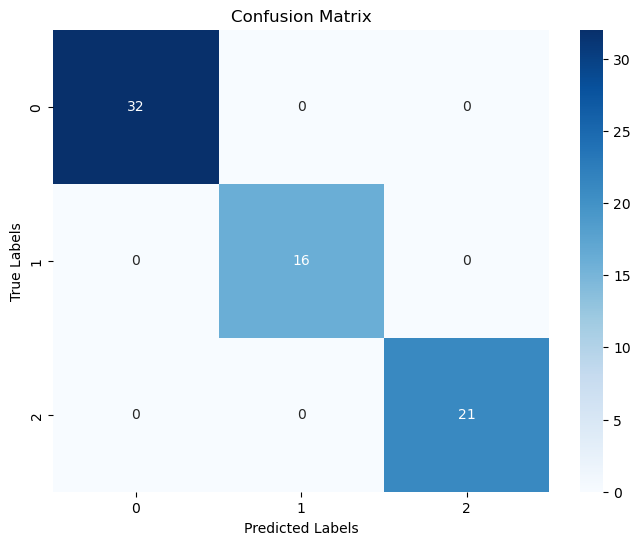

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [35]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(lr,x_train_sc,y_train,cv=5,scoring='accuracy')
print("Cross Validation Scores:", score)
print("Average CV Score:", score.mean())

Cross Validation Scores: [0.98181818 0.96363636 1.         1.         1.        ]
Average CV Score: 0.989090909090909


Feature Importances (Coefficients) from Logistic Regression Model:


,Feature,Importance
0,culmen_length_mm,-2.253855
1,culmen_depth_mm,0.957616
2,flipper_length_mm,-0.804536
5,island_Torgersen,0.511823
6,sex_MALE,0.499381
4,island_Dream,-0.161453
3,body_mass_g,-0.016729


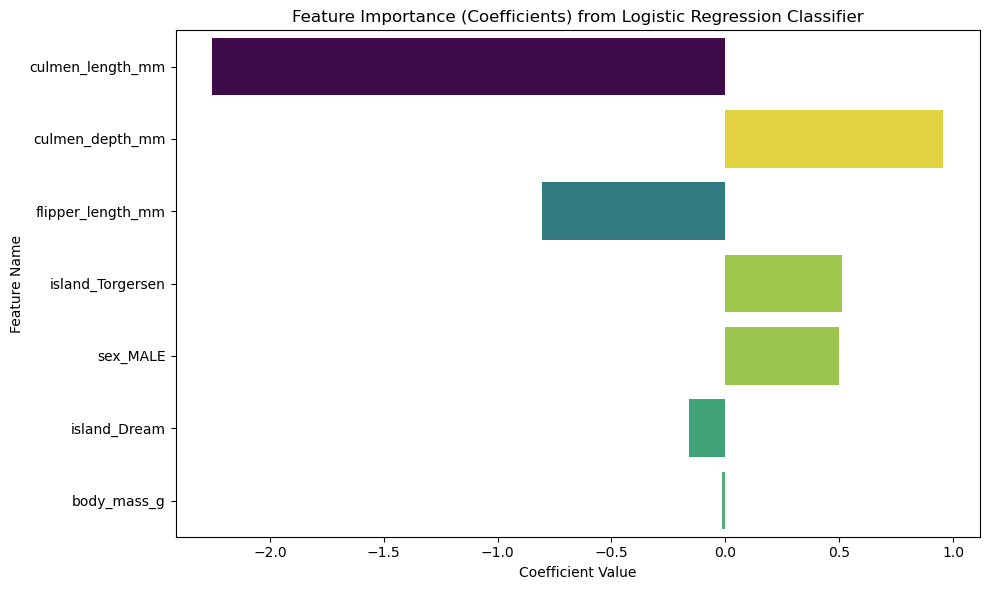

In [36]:
# feature importances (coefficients) from the Logistic Regression model
feature_importances = lr.coef_[0]

feature_names = x_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df['Absolute_Importance'] = abs(importance_df['Importance'])
importance_df = importance_df.sort_values(by='Absolute_Importance', ascending=False)

print("Feature Importances (Coefficients) from Logistic Regression Model:")
display(importance_df[['Feature', 'Importance']])

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis',hue='Importance',legend=False)
plt.title('Feature Importance (Coefficients) from Logistic Regression Classifier')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [38]:
dt_pred = dt.predict(x_test)

In [39]:
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report
print('Accuracy Score: ',accuracy_score(y_test,dt_pred))
print()
print('Confusion Matrix:')
print(confusion_matrix(y_test,dt_pred))
print()
print('Classification Report:')
print(classification_report(y_test,dt_pred))

Accuracy Score:  0.9855072463768116

Confusion Matrix:
[[31  0  1]
 [ 0 16  0]
 [ 0  0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       1.00      1.00      1.00        16
           2       0.95      1.00      0.98        21

    accuracy                           0.99        69
   macro avg       0.98      0.99      0.99        69
weighted avg       0.99      0.99      0.99        69



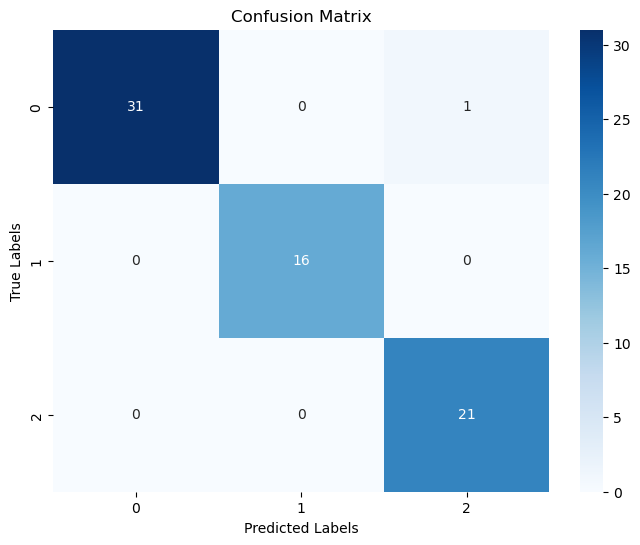

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [41]:
score = cross_val_score(dt,x_train,y_train,cv=5,scoring='accuracy')
print("Cross Validation Scores:", score)
print("Average CV Score:", score.mean())

Cross Validation Scores: [0.94545455 0.90909091 0.96363636 1.         1.        ]
Average CV Score: 0.9636363636363636


In [42]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

rf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [43]:
rf_pred = rf.predict(x_test)

In [44]:
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report
print('Accuracy Score:',accuracy_score(y_test,rf_pred))
print()
print('Confusion Matrix:')
print(confusion_matrix(y_test,rf_pred))
print()
print('Classification Report:')
print(classification_report(y_test,rf_pred))

Accuracy Score: 1.0

Confusion Matrix:
[[32  0  0]
 [ 0 16  0]
 [ 0  0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        21

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



In [45]:
score = cross_val_score(rf,x_train,y_train,cv=5,scoring='accuracy')
print("Cross Validation Scores:", score)
print("Average CV Score:", score.mean())

Cross Validation Scores: [0.98181818 0.98181818 0.96363636 1.         1.        ]
Average CV Score: 0.9854545454545456


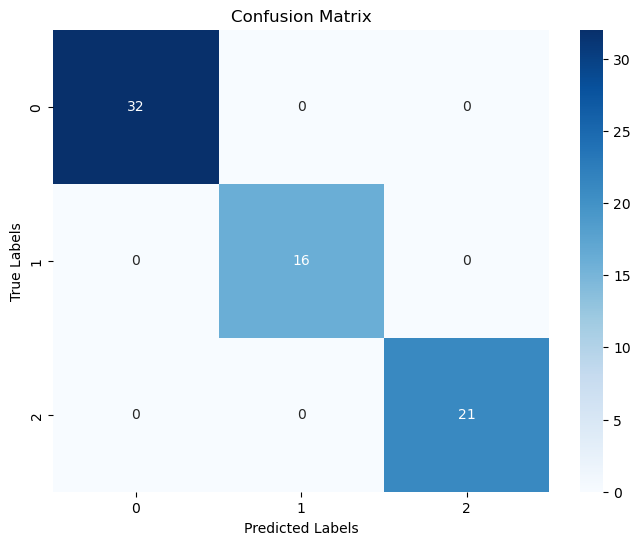

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Model Comparison
Now let’s compare the performance of the Logistic Regression, Decision Tree, and Random Forest models to identify which model performs best for penguin species classification

Model Comparison:


,Model,Accuracy
0,Logistic Regression,1.000000
2,Random Forest,1.000000
1,Decision Tree,0.985507


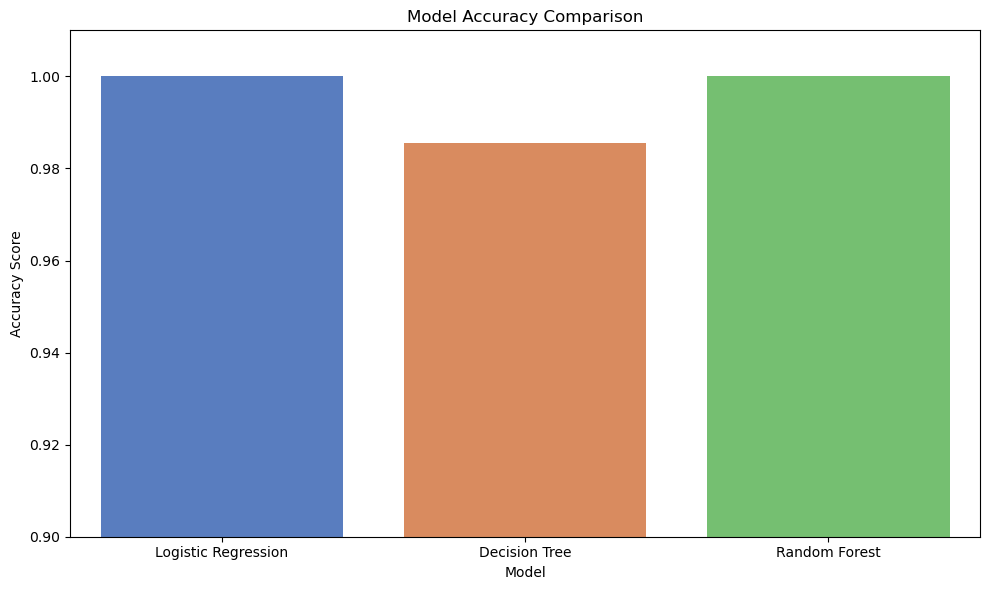

In [47]:
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracy_scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores
})

print("Model Comparison:")
display(comparison_df.sort_values(by='Accuracy', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='muted',hue='Model',legend=False)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

## Final Model Selection

    Based on the accuracy scores, confusion matrices, and overall model evaluation results, the Logistic Regression model achieved the highest accuracy (1.0) and classified all test samples correctly. The Random Forest model also performed exceptionally well with high prediction accuracy and can provide better robustness and generalization in more complex datasets, while the Decision Tree model showed slightly lower performance compared to the other models.

    The strong performance of Logistic Regression is likely due to the clear separation between penguin species based on the selected features. Overall, Logistic Regression proved to be the most effective and suitable model for this penguin species classification task and was therefore finalized for the project.


In [48]:
import pickle

In [50]:
pickle.dump(lr,open('penguin_model.pkl','wb'))
pickle.dump(sc,open('scaler.pkl','wb'))
pickle.dump(le,open('label_encoder.pkl','wb'))
pickle.dump(x.columns, open('feature_columns.pkl','wb'))
print("Model, scaler, label encoder, and feature columns saved successfully.")

Model, scaler, label encoder, and feature columns saved successfully.






# Conclusion 

> In this project, penguin species classification was performed using different machine learning models including Logistic Regression, Decision Tree, and Random Forest. The dataset was cleaned, encoded, scaled, and analyzed before model training. After evaluating the models using accuracy scores and confusion matrices, Logistic Regression achieved the best performance with perfect classification on the test data. Therefore, Logistic Regression was finalized as the most suitable model for this classification task.

